<a href="https://colab.research.google.com/github/Diego-Cano-bit/SIGNALS-CHILE/blob/main/Entrenamientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
def cargar_datos(ruta):
    datos = []
    etiquetas = []
    for clase in os.listdir(ruta):
        if clase == 'Nsr':
            etiqueta = 0
        elif clase == 'Chf':
            etiqueta = 1
        else:
            continue
        clase_ruta = os.path.join(ruta, clase)
        for archivo in os.listdir(clase_ruta):
            archivo_ruta = os.path.join(clase_ruta, archivo)
            # Cargar datos de CSV
            dato = pd.read_csv(archivo_ruta, header=None).values
            datos.append(dato)
            etiquetas.append(etiqueta)
    return np.array(datos), np.array(etiquetas)

**Funciones para graficar**

In [ ]:
def plot_metric(history, version, save_path, metric, metric_label, title, ylabel):
    """

    Args:
      history:
      version:
      save_path:
      metric:
      metric_label:
      title:
      ylabel:
    """
    plt.figure()
    plt.ylim(bottom=0)
    plt.plot(history.history[metric], label=f'{metric_label} de Entrenamiento', linewidth=2)
    plt.plot(history.history[f'val_{metric}'], label=f'{metric_label} de Validación', linewidth=2)
    plt.grid()
    plt.title(f'{title} - {version}')
    plt.ylabel(ylabel)
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.savefig(f'{save_path}/{version}_{metric}.png')
    plt.show()

def plot_accuracy(history, version, save_path):
    plot_metric(history, version, save_path, 'accuracy', 'Exactitud', 'Exactitud', 'Exactitud')

def plot_loss(history, version, save_path):
    plot_metric(history, version, save_path, 'loss', 'Pérdida', 'Pérdida', 'Pérdida')

def plot_precision(history, version, save_path):
    precision_key = [key for key in history.history.keys() if 'precision' in key.lower()][0]
    plot_metric(history, version, save_path, precision_key, 'Precisión', 'Precisión', 'Precisión')

def plot_recall(history, version, save_path):
    recall_key = [key for key in history.history.keys() if 'recall' in key.lower()][0]
    plot_metric(history, version, save_path, recall_key, 'Recall', 'Recall', 'Recall')

# Ejemplo de cómo llamar a las funciones
# plot_accuracy(history, 'v1', '/path/to/save')
# plot_loss(history, 'v1', '/path/to/save')
# plot_precision(history, 'v1', '/path/to/save')
# plot_recall(history, 'v1', '/path/to/save')


In [ ]:
def save_training_history(history, version, save_path):
    file_path = f'{save_path}/{version}_historial_entrenamiento.csv'

    with open(file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Escribir la cabecera
        writer.writerow(['epoch'] + list(history.history.keys()))
        # Escribir los datos
        for i in range(len(history.history['loss'])):
            row = [i + 1] + [history.history[key][i] for key in history.history.keys()]
            writer.writerow(row)

In [ ]:
import os
import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from datetime import datetime

def test_model(version, results_dir, x_test, y_test):
    """
    Realiza el test del modelo guardado, muestra las métricas de evaluación y guarda los resultados en un archivo CSV y la matriz de confusión como imagen.

    Parámetros:
    version: Versión del modelo.
    results_dir: Directorio donde se encuentra el modelo guardado.
    x_test: Datos de prueba.
    y_test: Etiquetas de prueba.
    """
    try:
        # Crear el directorio si no existe
        os.makedirs(results_dir, exist_ok=True)

        # Cargar el modelo guardado
        model_path = os.path.join(results_dir, f'model_{version}.h5')
        model = tf.keras.models.load_model(model_path)

        # Evaluar el modelo en los datos de prueba
        test_loss, test_accuracy, test_precision, test_recall = model.evaluate(x_test, y_test)

        # Predecir y calcular la puntuación F1
        y_pred = model.predict(x_test)
        y_pred_classes = (y_pred > 0.5).astype("int32")  # Para clasificaciones binarias
        f1 = f1_score(y_test, y_pred_classes, average='weighted')

        # Reporte de clasificación
        report = classification_report(y_test, y_pred_classes, output_dict=True)

        # Obtener la marca de tiempo actual
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

        # Guardar los resultados en un archivo CSV
        csv_path = os.path.join(results_dir, f'{version}_evaluacion_modelo_{timestamp}.csv')
        with open(csv_path, mode='w', newline='') as file:
            writer = csv.writer(file)
            # Escribir la cabecera
            writer.writerow(['Métrica', 'Valor'])
            writer.writerow(['Loss', test_loss])
            writer.writerow(['Accuracy', test_accuracy])
            writer.writerow(['Precision', test_precision])
            writer.writerow(['Recall', test_recall])
            writer.writerow(['F1 Score', f1])

            # Escribir las métricas detalladas del reporte de clasificación
            writer.writerow([])
            writer.writerow(['Clase', 'Precision', 'Recall', 'F1-Score', 'Support'])
            for class_label, metrics in report.items():
                if isinstance(metrics, dict):
                    writer.writerow([class_label, metrics['precision'], metrics['recall'], metrics['f1-score'], metrics['support']])

        print(f'Resultados de evaluación guardados en {csv_path}')

        # Mostrar y guardar la matriz de confusión como imagen
        conf_matrix = confusion_matrix(y_test, y_pred_classes)
        plt.figure(figsize=(10, 8))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title('Matriz de Confusión')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.savefig(os.path.join(results_dir, f'{version}_confusion_matrix_{timestamp}.png'))
        plt.show()

    except Exception as e:
        print(f'Ocurrió un error: {e}')

# Ejemplo de llamada a la función (asegúrate de reemplazar estos valores con tus datos y configuración)
# test_model(version='1', results_dir='resultados', x_test=datos_prueba, y_test=etiquetas_prueba)


**Main**



x_train shape: (3105, 256, 256)
y_train shape: (3105,)
x_val shape: (887, 256, 256)
y_val shape: (887,)
x_test shape: (446, 256, 256)
y_test shape: (446,)
Epoch 1/100
98/98 [==============================] - 29s 154ms/step - loss: 0.0941 - accuracy: 0.9681 - precision_1: 0.9704 - recall_1: 0.9721 - val_loss: 0.7283 - val_accuracy: 0.5536 - val_precision_1: 0.5536 - val_recall_1: 1.0000
Epoch 2/100
98/98 [==============================] - 12s 127ms/step - loss: 0.0231 - accuracy: 0.9926 - precision_1: 0.9930 - recall_1: 0.9936 - val_loss: 0.8973 - val_accuracy: 0.4464 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/100
98/98 [==============================] - 13s 130ms/step - loss: 0.0671 - accuracy: 0.9823 - precision_1: 0.9917 - recall_1: 0.9761 - val_loss: 4.6798 - val_accuracy: 0.4464 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/100
98/98 [==============================] - 13s 131ms/step - loss: 0.0219 - accuracy: 0.9923 - precision_1: 0.9930 - r

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


dict_keys(['loss', 'accuracy', 'precision_1', 'recall_1', 'val_loss', 'val_accuracy', 'val_precision_1', 'val_recall_1'])
{'loss': [0.09409785270690918, 0.02311965823173523, 0.06706007570028305, 0.02187310717999935, 0.016175171360373497, 0.03918495029211044, 0.04637755826115608, 0.015291649848222733, 0.010696407407522202, 0.05004093050956726, 0.020845521241426468, 0.007001879159361124, 0.017486922442913055, 0.009382404386997223, 0.007603967096656561, 0.006186135578900576, 0.003631112864241004, 0.006072458811104298, 0.002646765671670437, 0.0009092231630347669, 0.0015035571996122599, 0.00790189765393734, 0.004116005729883909, 0.008050819858908653, 0.013404542580246925, 0.002759730676189065, 0.004818480461835861, 0.015542111359536648, 0.0035066469572484493, 0.0019102091901004314, 0.002105441177263856, 0.001243092119693756, 0.0007500015781261027, 0.0002076149539789185, 0.0001647880271775648, 0.0001644778240006417, 0.00018372468184679747, 0.0004556461644824594, 0.0003240046789869666, 0.0006

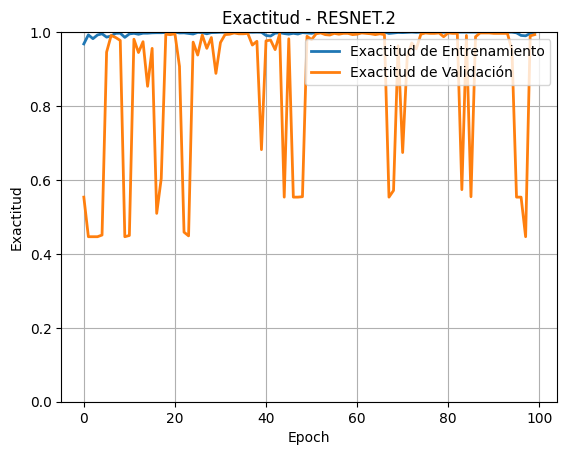

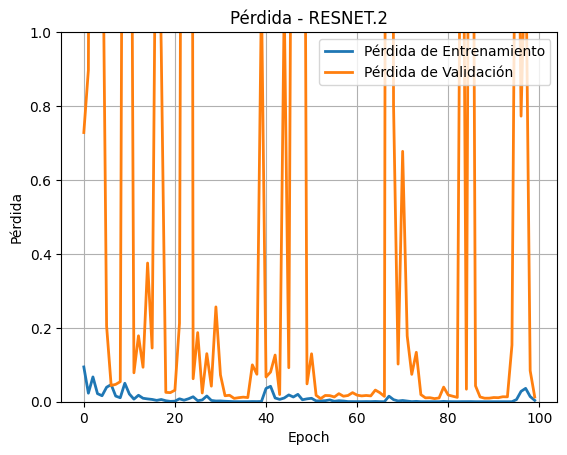

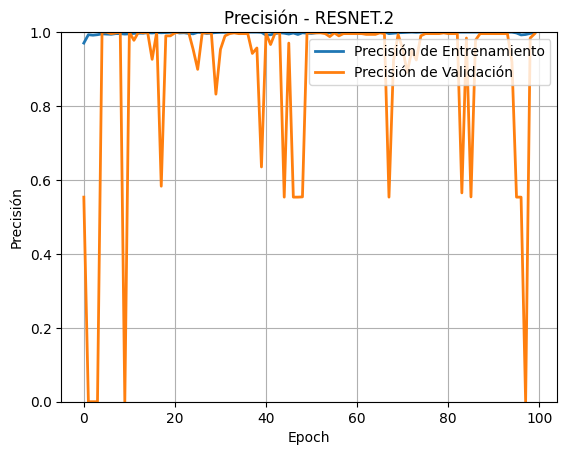

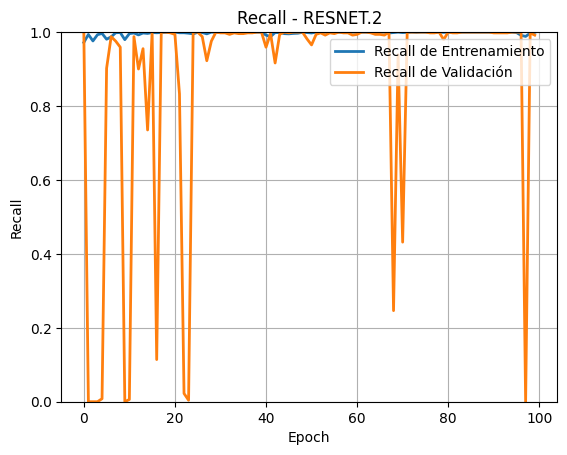

14/14 [==============================] - 1s 34ms/step
Resultados de evaluación guardados en /content/drive/MyDrive/Division_señales/Results/RESNET.2_evaluacion_modelo_20240628_161819.csv


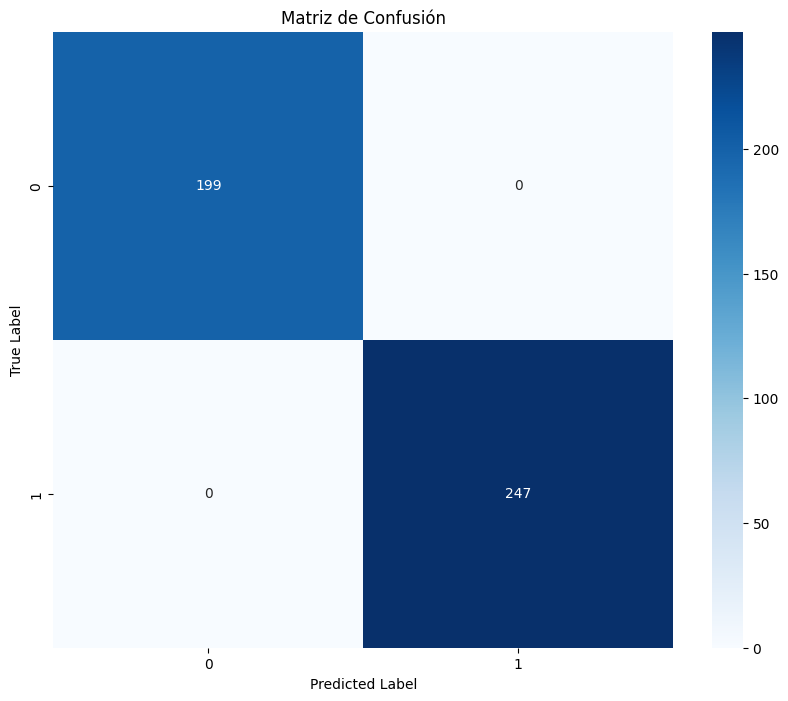

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from datetime import datetime
from tensorflow.keras.callbacks import EarlyStopping

# Asegúrate de que estas funciones están definidas en tu código
# from utils import cargar_datos, plot_accuracy, plot_loss, plot_precision, plot_recall, save_training_history

train_dir = '/content/drive/MyDrive/Division_señales/Train'
validation_dir = '/content/drive/MyDrive/Division_señales/Validation'
test_dir = '/content/drive/MyDrive/Division_señales/Test'
results_dir = '/content/drive/MyDrive/Division_señales/Results'

version = 'RESNET.2'

# Cargar datos
x_train, y_train = cargar_datos(train_dir)
x_val, y_val = cargar_datos(validation_dir)
x_test, y_test = cargar_datos(test_dir)

# Convertir los datos a tensores
x_train = x_train.astype('float32') / 255
x_val = x_val.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Imprimir tamaños de los conjuntos de datos
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_val shape:', x_val.shape)
print('y_val shape:', y_val.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

# Definir y compilar modelo

#ResNet
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D, GlobalAveragePooling2D, Dense, Add
from tensorflow.keras.models import Model

def residual_block(x, filters, kernel_size=3, stride=1):
    # Shortcut
    shortcut = x

    # First convolution
    x = Conv2D(filters, kernel_size=kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Second convolution
    x = Conv2D(filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Add shortcut
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=1, strides=stride)(shortcut)
    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

def ResNet(input_shape, num_classes):
    # Input
    inputs = Input(shape=input_shape)

    # Initial convolution
    x = Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Residual blocks
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    # Global average pooling
    x = GlobalAveragePooling2D()(x)

    # Output layer
    outputs = Dense(num_classes, activation='sigmoid')(x)

    # Create model
    model = Model(inputs, outputs)
    return model

# Create the ResNet model for binary classification of 64x64 images in grayscale
model = ResNet((256, 256, 1), 1)
# Compilar modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Definir el callback EarlyStopping
#early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# Entrenar el modelo con EarlyStopping
history = model.fit(x_train,
                    y_train,
                    epochs=100,  # Asegúrate de establecer un número suficientemente alto de épocas
                    verbose=1,
                    validation_data=(x_val, y_val))
                    #callbacks=[early_stopping])

# Guardar el modelo
model.save(f'{results_dir}/model_{version}.h5')

# Imprimir las claves del historial de entrenamiento para identificar las métricas
print(history.history.keys())

# Imprimir el historial de entrenamiento
print(history.history)

# Asegúrate de que estas funciones están definidas
plot_accuracy(history, version, results_dir)
plot_loss(history, version, results_dir)
plot_precision(history, version, results_dir)
plot_recall(history, version, results_dir)

# Guardar el historial de entrenamiento
save_training_history(history, version, results_dir)

# Evaluar modelo
test_model(version, results_dir, x_test, y_test)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
